In [4]:
import pandas as pd
import numpy  as np
import seaborn as sns
import matplotlib.pyplot as plt
import importlib
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score,roc_auc_score,roc_curve,confusion_matrix,ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression



In [5]:
df = pd.read_csv('aug_train.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19061 entries, 0 to 19060
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city                    19061 non-null  int64  
 1   city_development_index  19061 non-null  float64
 2   gender                  19061 non-null  int64  
 3   relevent_experience     19061 non-null  int64  
 4   enrolled_university     19061 non-null  int64  
 5   education_level         19061 non-null  int64  
 6   major_discipline        19061 non-null  int64  
 7   experience              19061 non-null  int64  
 8   company_size            19061 non-null  int64  
 9   company_type            19061 non-null  int64  
 10  last_new_job            19061 non-null  int64  
 11  training_hours          19061 non-null  int64  
 12  target                  19061 non-null  float64
dtypes: float64(2), int64(11)
memory usage: 1.9 MB


In [6]:
if 'enrollee_id' in df.columns:
    df=df.drop(columns=['enrollee_id'])
df.head()

,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,5,0.920,1,0,2,0,5,21,4,5,0,36,1.0
1,77,0.776,1,1,2,0,5,6,4,5,4,47,0.0
2,64,0.624,1,1,0,0,5,15,4,5,5,83,0.0
3,14,0.789,1,1,2,0,1,20,4,5,5,52,1.0
4,50,0.767,1,0,2,2,5,21,4,1,3,8,0.0


In [7]:
print("missing val:",df.isnull().sum())
print("Duplicates :",df.duplicated().sum())


missing val: city                      0
city_development_index    0
gender                    0
relevent_experience       0
enrolled_university       0
education_level           0
major_discipline          0
experience                0
company_size              0
company_type              0
last_new_job              0
training_hours            0
target                    0
dtype: int64
Duplicates : 0


In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df['experience']=df['experience'].replace({'>20':21,'<1':0})
df['last_new_job']=df['last_new_job'].replace({'>4':5,'never':0})
df.head()

,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,5,0.920,1,0,2,0,5,21,4,5,0,36,1.0
1,77,0.776,1,1,2,0,5,6,4,5,4,47,0.0
2,64,0.624,1,1,0,0,5,15,4,5,5,83,0.0
3,14,0.789,1,1,2,0,1,20,4,5,5,52,1.0
4,50,0.767,1,0,2,2,5,21,4,1,3,8,0.0


In [10]:
df['experience']=pd.to_numeric(df['experience'],errors='coerce')
df['last_new_job']=pd.to_numeric(df['last_new_job'],errors='coerce')

In [11]:
df.to_csv('DOC-20260907-WA0004.csv',index=False)

In [12]:

select_cols = [
    'city_development_index',
    'relevent_experience',
    'experience',
    'education_level',
    'last_new_job',
    'training_hours',
    'company_size',
    'company_type',
]
X = df[select_cols]
y = df['target']

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


num_features = [
    'city_development_index',
    'experience',
    'last_new_job',
    'training_hours',
]
cat_features = [
    'relevent_experience',
    'education_level',
    'company_size',
    'company_type',
]


num_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]
)


cat_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore')),
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features),
    ]
)


x_train_prepared = preprocessor.fit_transform(x_train)
x_test_prepared = preprocessor.transform(x_test)


lr_model_balanced = LogisticRegression(
    max_iter=1000, random_state=42, class_weight='balanced'
)
lr_model_balanced.fit(x_train_prepared, y_train)

rf_model_balanced = RandomForestClassifier(
    n_estimators=100, random_state=42, class_weight='balanced'
)
rf_model_balanced.fit(x_train_prepared, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

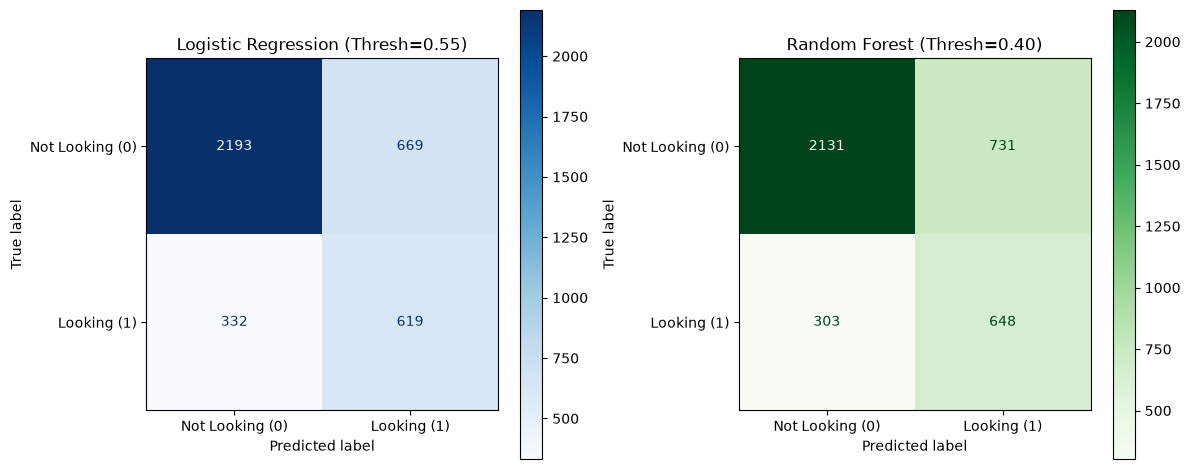

=== Logistic Regression Optimized Results ===
Best Threshold: 0.55
ROC_AUC: 0.7628183507595447
Accuracy: 0.7374770521898767
F1 Score: 0.552925413130862
Classification Report:
               precision    recall  f1-score   support

         0.0       0.87      0.77      0.81      2862
         1.0       0.48      0.65      0.55       951

    accuracy                           0.74      3813
   macro avg       0.67      0.71      0.68      3813
weighted avg       0.77      0.74      0.75      3813


=== Random Forest Optimized Results ===
Best Threshold: 0.40
ROC_AUC: 0.7544335250473773
Accuracy: 0.7288224495148178
F1 Score: 0.5562231759656653
Classification Report:
               precision    recall  f1-score   support

         0.0       0.88      0.74      0.80      2862
         1.0       0.47      0.68      0.56       951

    accuracy                           0.73      3813
   macro avg       0.67      0.71      0.68      3813
weighted avg       0.77      0.73      0.74      3813

In [25]:
y_pred_lr=lr_model_balanced.predict(x_test_prepared)
y_proba_lr=lr_model_balanced.predict_proba(x_test_prepared)[:,1]
y_pred_rf=rf_model_balanced.predict(x_test_prepared)
y_proba_rf=rf_model_balanced.predict_proba(x_test_prepared)[:,1]

thresholds = np.arange(0.3, 0.7, 0.05)

best_thresh_lr = 0.5
best_f1_lr = 0
for th in thresholds:
    preds = (y_proba_lr >= th).astype(int)
    current_f1 = f1_score(y_test, preds)
    if current_f1 > best_f1_lr:
        best_f1_lr = current_f1
        best_thresh_lr = th

best_thresh_rf = 0.5
best_f1_rf = 0
for th in thresholds:
    preds = (y_proba_rf >= th).astype(int)
    current_f1 = f1_score(y_test, preds)
    if current_f1 > best_f1_rf:
        best_f1_rf = current_f1
        best_thresh_rf = th


y_pred_lr_opt = (y_proba_lr >= best_thresh_lr).astype(int)
y_pred_rf_opt = (y_proba_rf >= best_thresh_rf).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_log = confusion_matrix(y_test, y_pred_lr_opt)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=['Not Looking (0)', 'Looking (1)'])
disp_log.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title(f'Logistic Regression (Thresh={best_thresh_lr:.2f})')

cm_rf = confusion_matrix(y_test, y_pred_rf_opt)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Not Looking (0)', 'Looking (1)'])
disp_rf.plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title(f'Random Forest (Thresh={best_thresh_rf:.2f})')

plt.tight_layout()
plt.show()


print('=== Logistic Regression Optimized Results ===')
print(f'Best Threshold: {best_thresh_lr:.2f}')
print('ROC_AUC:', roc_auc_score(y_test, y_proba_lr))
print('Accuracy:', accuracy_score(y_test, y_pred_lr_opt))
print('F1 Score:', f1_score(y_test, y_pred_lr_opt))
print('Classification Report:\n', classification_report(y_test, y_pred_lr_opt))

print('\n=== Random Forest Optimized Results ===')
print(f'Best Threshold: {best_thresh_rf:.2f}')
print('ROC_AUC:', roc_auc_score(y_test, y_proba_rf))
print('Accuracy:', accuracy_score(y_test, y_pred_rf_opt))
print('F1 Score:', f1_score(y_test, y_pred_rf_opt))
print('Classification Report:\n', classification_report(y_test, y_pred_rf_opt))

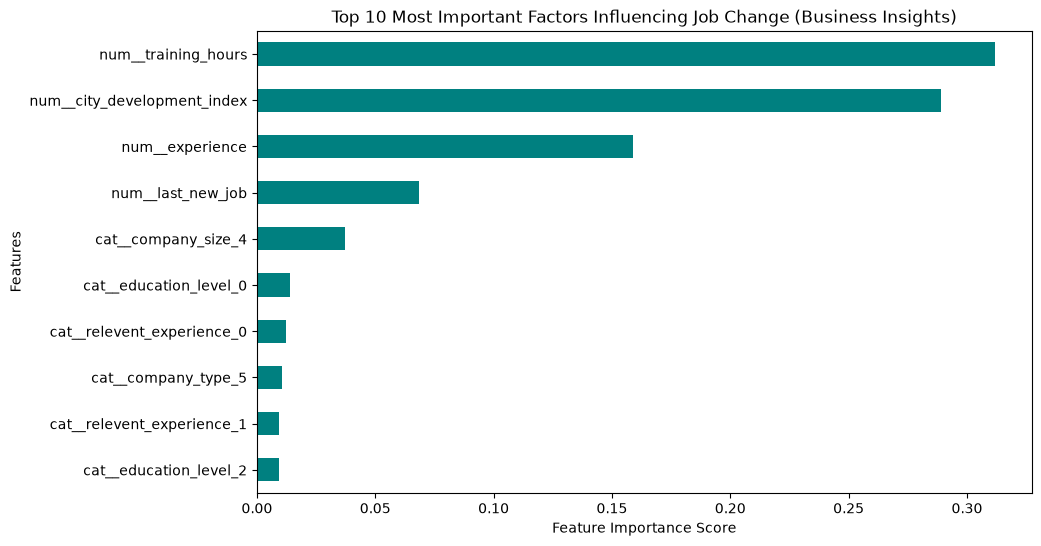

--- Top 3 Most Important Factors Influencing Candidate Decisions (Business Insights) ---
1. Factor: num__training_hours (Importance Score: 0.3118)
2. Factor: num__city_development_index (Importance Score: 0.2890)
3. Factor: num__experience (Importance Score: 0.1588)


In [14]:
importlib.reload(plt)
feature_importances = pd.Series(rf_model_balanced.feature_importances_, index=preprocessor.get_feature_names_out())

plt.figure(figsize=(10, 6))
feature_importances.nlargest(10).sort_values().plot(kind='barh', color='teal')
plt.title('Top 10 Most Important Factors Influencing Job Change (Business Insights)')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.show()

top_factors = feature_importances.nlargest(3)
print("--- Top 3 Most Important Factors Influencing Candidate Decisions (Business Insights) ---")
for idx, (feature, score) in enumerate(top_factors.items(), 1):
    print(f"{idx}. Factor: {feature} (Importance Score: {score:.4f})")

C:\Users\lina\AppData\Local\Temp\ipykernel_13548\1843962497.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y='training_hours', palette='pastel')


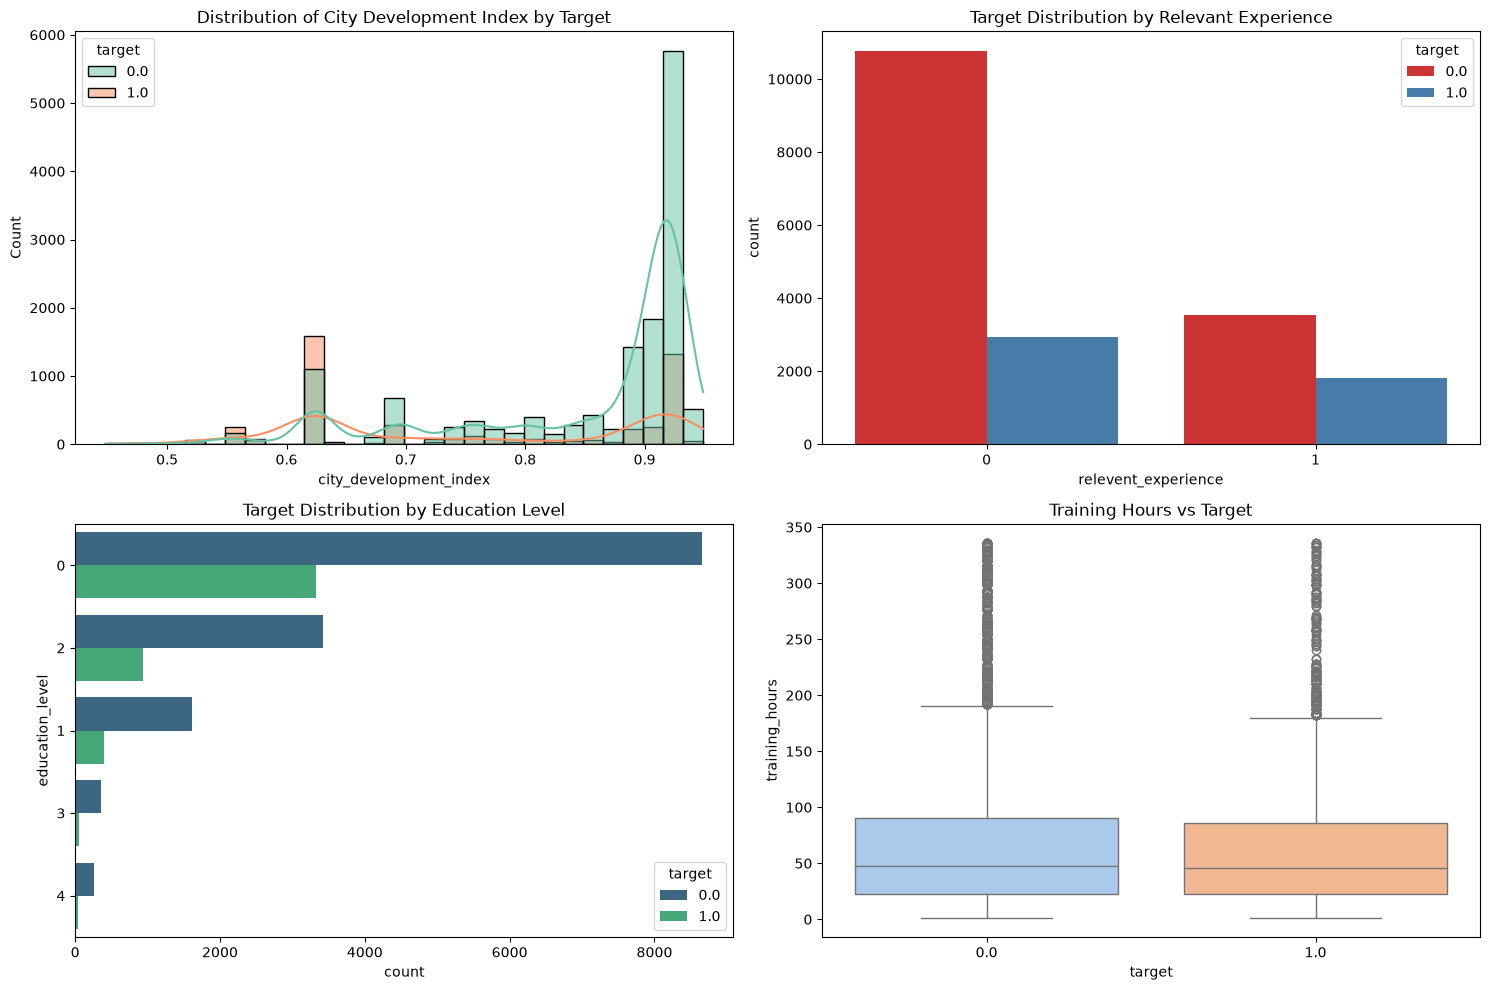

In [15]:
importlib.reload(plt)
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.histplot(data=df, x='city_development_index', hue='target', kde=True, palette='Set2', bins=30)
plt.title('Distribution of City Development Index by Target')

plt.subplot(2, 2, 2)
sns.countplot(data=df, x='relevent_experience', hue='target', palette='Set1')
plt.title('Target Distribution by Relevant Experience')

plt.subplot(2, 2, 3)
sns.countplot(data=df, y='education_level', hue='target', palette='viridis', order=df['education_level'].value_counts().index)
plt.title('Target Distribution by Education Level')

plt.subplot(2, 2, 4)
sns.boxplot(data=df, x='target', y='training_hours', palette='pastel')
plt.title('Training Hours vs Target')

plt.tight_layout()
plt.show()

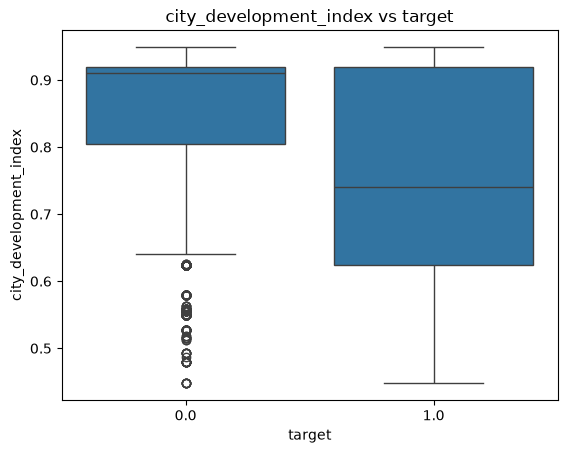

In [16]:
importlib.reload(plt)
sns.boxplot(x='target', y='city_development_index', data=df)
plt.title('city_development_index vs target')
plt.xlabel('target')
plt.ylabel('city_development_index')

plt.show()

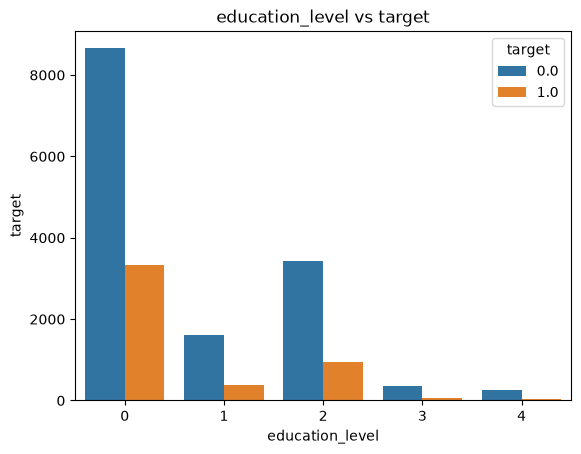

In [17]:
sns.countplot(x='education_level', hue='target', data=df)
plt.title('education_level vs target')
plt.xlabel('education_level')
plt.ylabel('target')

plt.show()



In [18]:
education_target= pd.crosstab(
    df['education_level'],
    df['target'],
    normalize='index'
    ) *100

print(education_target)

target                 0.0        1.0
education_level                      
0                72.214339  27.785661
1                80.487805  19.512195
2                78.538603  21.461397
3                85.990338  14.009662
4                86.557377  13.442623


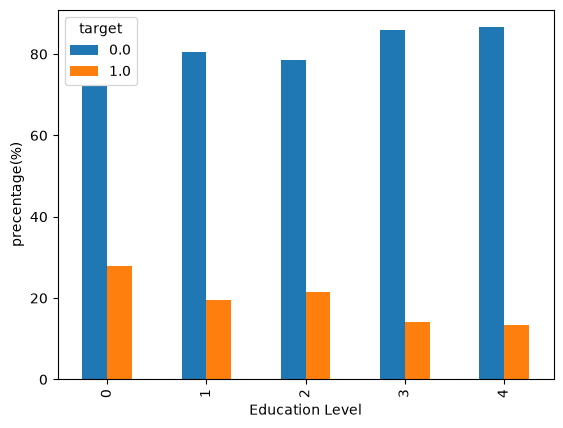

In [19]:
education_target.plot(kind='bar')
plt.title=('Target percentage by Education Level')
plt.xlabel('Education Level')
plt.ylabel('precentage(%)')
plt.show()

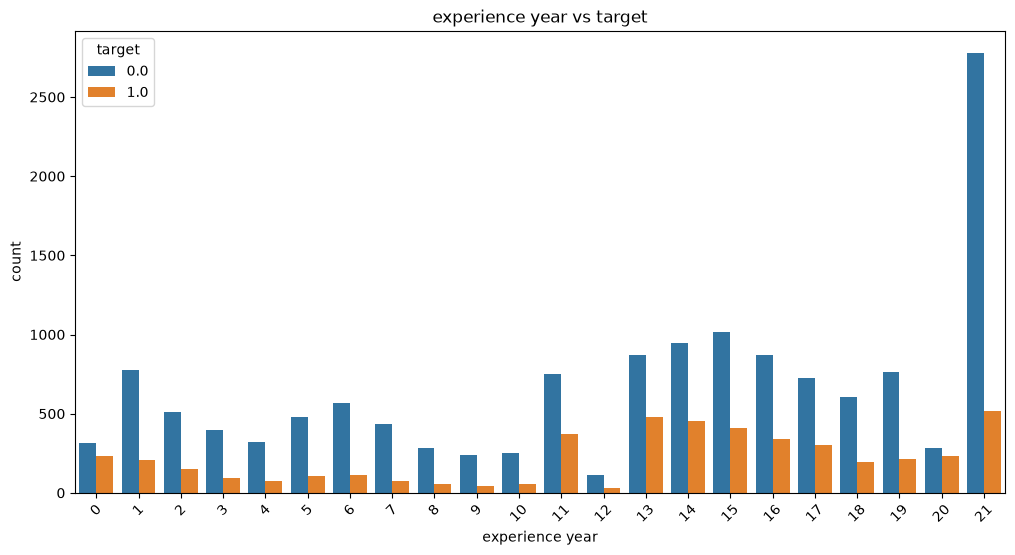

In [20]:
importlib.reload(plt)


plt.figure(figsize=(12, 6))

sns.countplot(
    x='experience',
    hue='target',
    data=df
)

plt.title("experience year vs target")
plt.xlabel("experience year")
plt.ylabel("count")
plt.xticks(rotation=45)

plt.show()

Text(0, 0.5, 'Training hours')

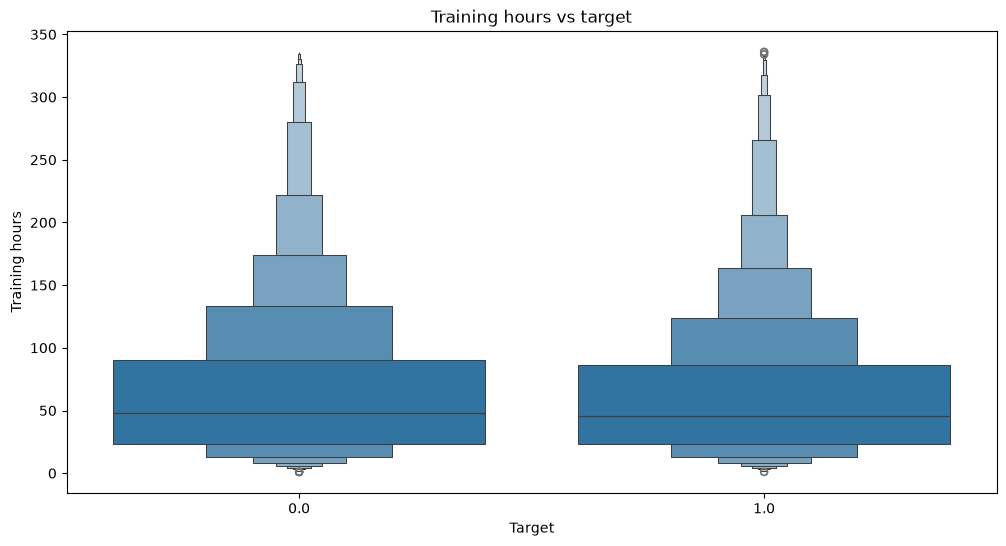

In [21]:
importlib.reload(plt)


plt.figure(figsize=(12, 6))
sns.boxenplot(
    x='target',
    y='training_hours',
    data=df
)
plt.title('Training hours vs target')
plt.xlabel('Target')
plt.ylabel('Training hours')

In [22]:
Major_target= pd.crosstab(
    df['major_discipline'],
    df['target'],
    normalize='index'
    ) *100

print(Major_target)

target                  0.0        1.0
major_discipline                      
0                 79.051383  20.948617
1                 73.700306  26.299694
2                 78.923767  21.076233
3                 75.336323  24.663677
4                 73.228346  26.771654
5                 74.912831  25.087169


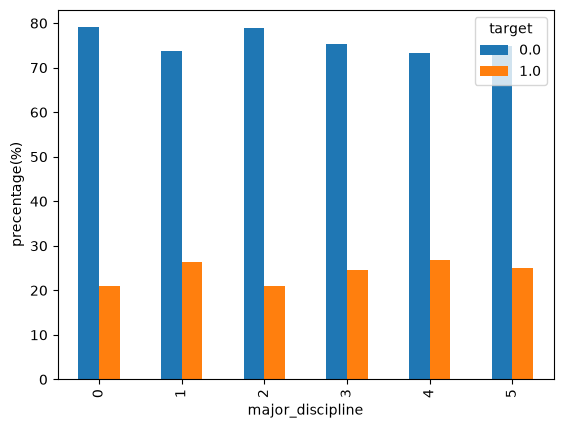

In [23]:
Major_target.plot(kind='bar')
plt.title=('Target percentage vs major_discipline')
plt.xlabel('major_discipline')
plt.ylabel('precentage(%)')
plt.show()

C:\Users\lina\AppData\Local\Temp\ipykernel_13548\1646263670.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


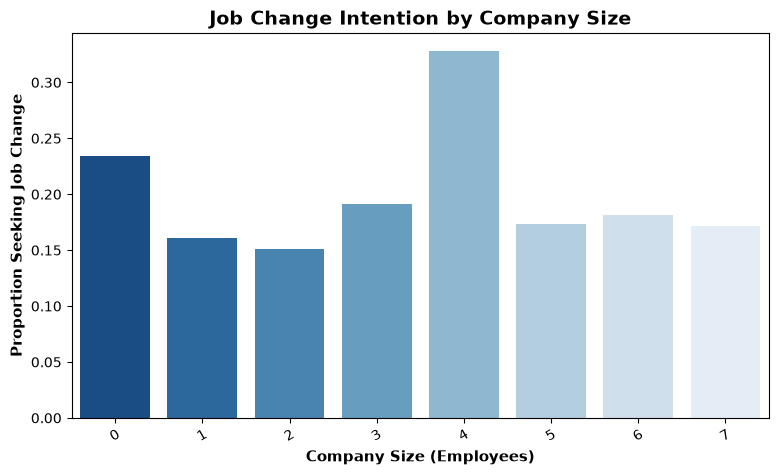

In [24]:
importlib.reload(plt)

df_clean = df.dropna(subset=['company_size', 'target']).copy()

df_clean['target'] = df_clean['target'].astype(float)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=df_clean,
    x='company_size',
    y='target',
    errorbar=None,
    palette='Blues_r'
)

plt.title('Job Change Intention by Company Size', fontsize=14, fontweight='bold')
plt.xlabel('Company Size (Employees)', fontsize=11, fontweight='bold')
plt.ylabel('Proportion Seeking Job Change', fontsize=11, fontweight='bold')
plt.xticks(rotation=30)

plt.savefig('company_size_chart.png', dpi=300, bbox_inches='tight')
plt.show()